In [33]:
import os
import glob
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [34]:
cd C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\12.drep\drep_Pvulgatus\03.coverm

C:\Users\tr432\Desktop\Roh\_Study_Design\25.05.02~_Gut-Lung_Axis\Exp1+1-S\MGX\12.drep\drep_Pvulgatus\03.coverm


In [35]:
# =========================
# Input / output
# =========================
IN_DIR = "."   # C01.tsv, C02.tsv, V01.tsv 파일들이 있는 폴더
OUTFILE = "coverm_merged_long.csv"

TARGET_GENOME = "C02_concoct.31"  # 대표 P. vulgatus MAG 이름

# =========================
# Read all tsv files
# =========================
files = sorted(glob.glob(os.path.join(IN_DIR, "*.tsv")))

dfs = []

for f in files:
    tmp = pd.read_csv(f, sep="\t")
    
    # 파일명에서 SampleID 추출: C01.tsv -> C01
    sample_id = os.path.basename(f).replace(".tsv", "")
    tmp["SampleID"] = sample_id
    
    dfs.append(tmp)

df_all = pd.concat(dfs, ignore_index=True)

# =========================
# Clean columns
# =========================
df_all.columns = [c.strip() for c in df_all.columns]

# 숫자형 변환
num_cols = ["Relative Abundance (%)", "Trimmed Mean", "Covered Bases", "Length", "Read Count"]
for c in num_cols:
    if c in df_all.columns:
        df_all[c] = pd.to_numeric(df_all[c], errors="coerce")

# Group 자동 지정
df_all["Group"] = np.where(df_all["SampleID"].str.startswith("C"), "Control",
                   np.where(df_all["SampleID"].str.startswith("V"), "VNAM", "Other"))

# Covered fraction 계산
df_all["Covered_fraction"] = df_all["Covered Bases"] / df_all["Length"]

# 보기 편한 column명 추가
df_all = df_all.rename(columns={
    "Relative Abundance (%)": "Relative_abundance",
    "Trimmed Mean": "Mean_coverage",
    "Read Count": "Read_count",
    "Covered Bases": "Covered_bases"
})

# =========================
# unmapped 제거
# =========================
df_mapped = df_all[df_all["Genome"] != "unmapped"].copy()

# =========================
# 특정 representative MAG만 추출
# =========================
df_target = df_mapped[df_mapped["Genome"] == TARGET_GENOME].copy()

# 저장
df_target.to_csv(OUTFILE, index=False)

print(df_target.head())
print(f"Saved: {OUTFILE}")

                         Sample          Genome  Relative_abundance  \
1  C01_host_removed_R1.fastq.gz  C02_concoct.31            8.352347   
3  C02_host_removed_R1.fastq.gz  C02_concoct.31           11.806421   
5  C03_host_removed_R1.fastq.gz  C02_concoct.31            9.510801   
7  C09_host_removed_R1.fastq.gz  C02_concoct.31           17.997206   
9  C10_host_removed_R1.fastq.gz  C02_concoct.31            9.148717   

   Mean_coverage  Covered_bases     Length  Read_count SampleID    Group  \
1      149.80923      4916936.0  4917160.0   4898598.0      C01  Control   
3      178.52339      4916976.0  4917160.0   5871890.0      C02  Control   
5      203.32964      4908677.0  4917160.0   6664384.0      C03  Control   
7      222.99135      4908679.0  4917160.0   7318126.0      C09  Control   
9       90.34755      4908691.0  4917160.0   2971096.0      C10  Control   

   Covered_fraction  
1          0.999954  
3          0.999963  
5          0.998275  
7          0.998275  
9     

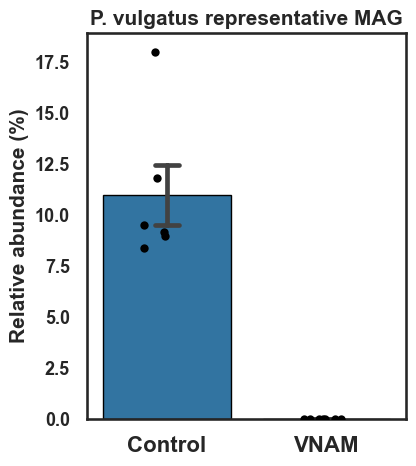

In [37]:
df = pd.read_csv("coverm_merged_long.csv")

OUT_DIR = "coverm_plots"
os.makedirs(OUT_DIR, exist_ok=True)

GROUP_ORDER = ["Control", "VNAM"]

sns.set_context("talk")
sns.set_style("white")

plt.figure(figsize=(4.5, 5))

ax = sns.barplot(
    data=df,
    x="Group",
    y="Relative_abundance",
    order=GROUP_ORDER,
    estimator="mean",
    errorbar="se",
    edgecolor="black",
    linewidth=1.0,
    capsize=0.15
)

sns.stripplot(
    data=df,
    x="Group",
    y="Relative_abundance",
    order=GROUP_ORDER,
    color="black",
    size=6,
    jitter=0.18,
    ax=ax
)

plt.xlabel("")
plt.ylabel("Relative abundance (%)", fontsize=15, fontweight="bold")
plt.title("P. vulgatus representative MAG", fontsize=15, fontweight="bold")

plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "CoverM_relative_abundance.png"), dpi=500, bbox_inches="tight")
plt.show()

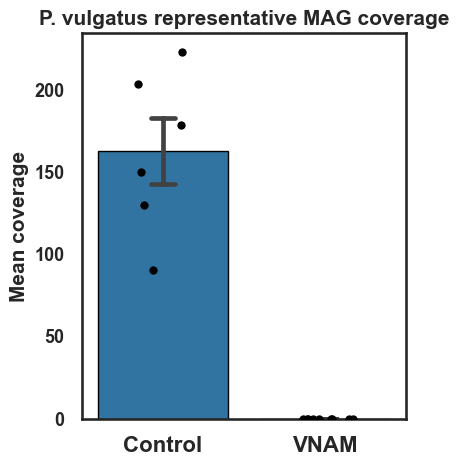

In [38]:
plt.figure(figsize=(4.5, 5))

ax = sns.barplot(
    data=df,
    x="Group",
    y="Mean_coverage",
    order=GROUP_ORDER,
    estimator="mean",
    errorbar="se",
    edgecolor="black",
    linewidth=1.0,
    capsize=0.15
)

sns.stripplot(
    data=df,
    x="Group",
    y="Mean_coverage",
    order=GROUP_ORDER,
    color="black",
    size=6,
    jitter=0.18,
    ax=ax
)

plt.xlabel("")
plt.ylabel("Mean coverage", fontsize=15, fontweight="bold")
plt.title("P. vulgatus representative MAG coverage", fontsize=15, fontweight="bold")

plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "CoverM_mean_coverage.png"), dpi=500, bbox_inches="tight")
plt.show()

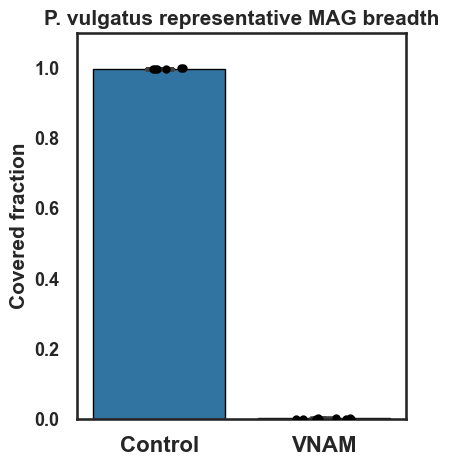

In [39]:
plt.figure(figsize=(4.5, 5))

ax = sns.barplot(
    data=df,
    x="Group",
    y="Covered_fraction",
    order=GROUP_ORDER,
    estimator="mean",
    errorbar="se",
    edgecolor="black",
    linewidth=1.0,
    capsize=0.15
)

sns.stripplot(
    data=df,
    x="Group",
    y="Covered_fraction",
    order=GROUP_ORDER,
    color="black",
    size=6,
    jitter=0.18,
    ax=ax
)

plt.xlabel("")
plt.ylabel("Covered fraction", fontsize=15, fontweight="bold")
plt.title("P. vulgatus representative MAG breadth", fontsize=15, fontweight="bold")

plt.xticks(fontsize=16, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')
plt.ylim(0, 1.1)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "CoverM_covered_fraction.png"), dpi=500, bbox_inches="tight")
plt.show()

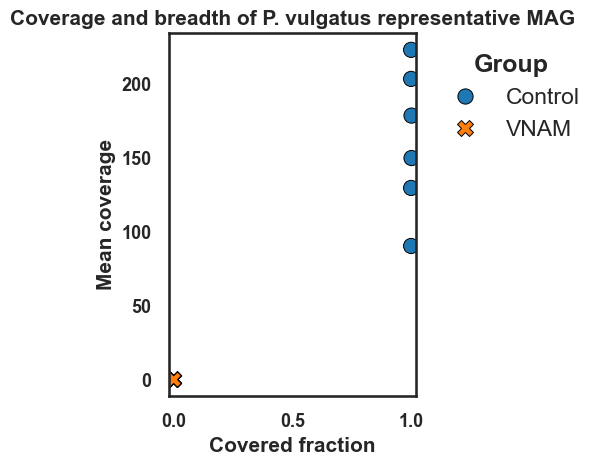

In [40]:
plt.figure(figsize=(5.5, 5))

ax = sns.scatterplot(
    data=df,
    x="Covered_fraction",
    y="Mean_coverage",
    hue="Group",
    style="Group",
    s=120,
    edgecolor="black",
    linewidth=0.7
)

plt.xlabel("Covered fraction", fontsize=15, fontweight="bold")
plt.ylabel("Mean coverage", fontsize=15, fontweight="bold")
plt.title("Coverage and breadth of P. vulgatus representative MAG", fontsize=15, fontweight="bold")

plt.xticks(fontsize=13, fontweight='bold')
plt.yticks(fontsize=13, fontweight='bold')
plt.xlim(-0.02, 1.02)

leg = ax.legend(title="Group", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
leg.get_title().set_fontweight("bold")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "CoverM_coverage_breadth_scatter.png"), dpi=500, bbox_inches="tight")
plt.show()

In [41]:
df_wide = df_mapped.pivot_table(
    index="Genome",
    columns="SampleID",
    values="Relative_abundance",
    fill_value=0
)

df_wide.to_csv("coverm_relative_abundance_wide.csv")

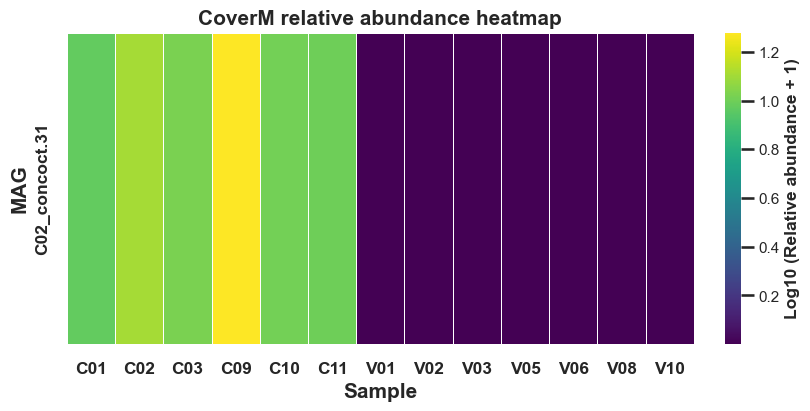

In [61]:
mat = pd.read_csv("coverm_relative_abundance_wide.csv", index_col=0)
mat_log = np.log10(mat + 1)

# row 수에 맞게 높이 조절
fig_h = max(2.3, mat_log.shape[0] * 4)
fig_w = max(8, mat_log.shape[1] * 0.1)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

hm = sns.heatmap(
    mat_log,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "log10(relative abundance + 1)"},
    ax=ax
)

plt.xlabel("Sample", fontsize=15, fontweight="bold")
plt.ylabel("MAG", fontsize=15, fontweight="bold")
plt.title("CoverM relative abundance heatmap", fontsize=15, fontweight="bold")

plt.xticks(fontsize=12.5, fontweight='bold')
plt.yticks(fontsize=12.5, fontweight='bold')

# colorbar 글자크기
cbar = hm.collections[0].colorbar
cbar.ax.set_ylabel("Log10 (Relative abundance + 1)", fontsize=12.5, fontweight="bold")
cbar.ax.tick_params(labelsize=11)

plt.savefig(os.path.join(OUT_DIR, "CoverM_relative_abundance_heatmap.png"), dpi=500, bbox_inches="tight")
plt.show()